<a href="https://colab.research.google.com/github/bahador1/BahadorColabNotes/blob/main/kale_haji_kishmish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

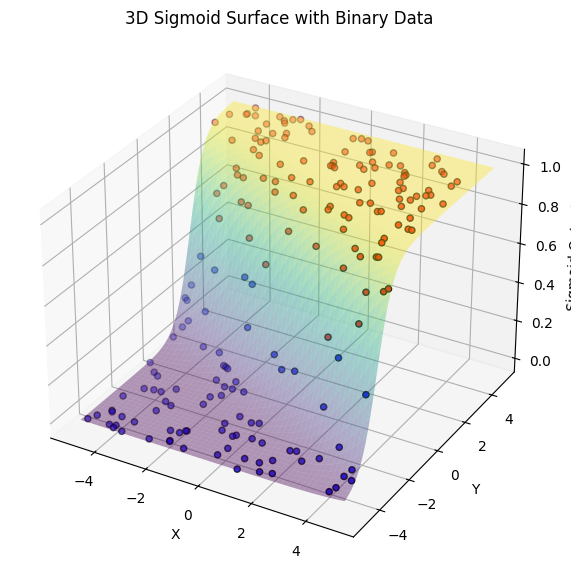

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------
# 1️⃣ Generate random 2D data
# -----------------------
np.random.seed(42)
n = 200

x = np.random.uniform(-5, 5, n)
y = np.random.uniform(-5, 5, n)

# Linear function
linear_part = x + 2*y + 1

# Binary labels
labels = (linear_part > 0).astype(int)

# -----------------------
# 2️⃣ Sigmoid function
# -----------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_sigmoid = sigmoid(linear_part)

# -----------------------
# 3️⃣ Create grid for surface
# -----------------------
xx, yy = np.meshgrid(
    np.linspace(-5, 5, 100),
    np.linspace(-5, 5, 100)
)

zz = sigmoid(xx + 2*yy + 1)

# -----------------------
# 4️⃣ 3D Visualization
# -----------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface (sigmoid)
ax.plot_surface(xx, yy, zz, alpha=0.4, cmap='viridis')

# Scatter data points
ax.scatter(x, y, z_sigmoid, c=labels, cmap='bwr', edgecolor='k')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Sigmoid Output")
ax.set_title("3D Sigmoid Surface with Binary Data")

plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -----------------------
# 1️⃣ Data
# -----------------------
np.random.seed(42)
n = 200

x = np.random.uniform(-5, 5, n)
y = np.random.uniform(-5, 5, n)

linear_part = x + 2*y + 1
labels = (linear_part > 0).astype(int)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_sigmoid = sigmoid(linear_part)

# -----------------------
# 2️⃣ Grid for surfaces
# -----------------------
xx, yy = np.meshgrid(
    np.linspace(-5, 5, 100),
    np.linspace(-5, 5, 100)
)

zz_linear = xx + 2*yy + 1
zz_sigmoid = sigmoid(zz_linear)

# -----------------------
# 3️⃣ Subplots
# -----------------------
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=("Linear Plane: z = x + 2y + 1",
                    "Sigmoid Surface")
)

# ---- Linear plane
fig.add_trace(
    go.Surface(x=xx, y=yy, z=zz_linear,
               colorscale='Viridis',
               opacity=0.7),
    row=1, col=1
)

fig.add_trace(
    go.Scatter3d(
        x=x, y=y, z=linear_part,
        mode='markers',
        marker=dict(size=4,
                    color=labels,
                    colorscale='RdBu'),
        showlegend=False
    ),
    row=1, col=1
)

# ---- Sigmoid surface
fig.add_trace(
    go.Surface(x=xx, y=yy, z=zz_sigmoid,
               colorscale='Viridis',
               opacity=0.7),
    row=1, col=2
)

fig.add_trace(
    go.Scatter3d(
        x=x, y=y, z=z_sigmoid,
        mode='markers',
        marker=dict(size=4,
                    color=labels,
                    colorscale='RdBu'),
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    height=600,
    width=1200,
    title_text="Linear Plane vs Sigmoid Surface",
)

fig.show()

ℓ_obs = 0.4800
p(ℓ_obs | Q̃_in(x,y)) = 1.792417
p(ℓ_obs | Q̃_out(x,y)) = 0.244300
Λ(ℓ_obs;x,y) = 7.336939
Prediction = Member


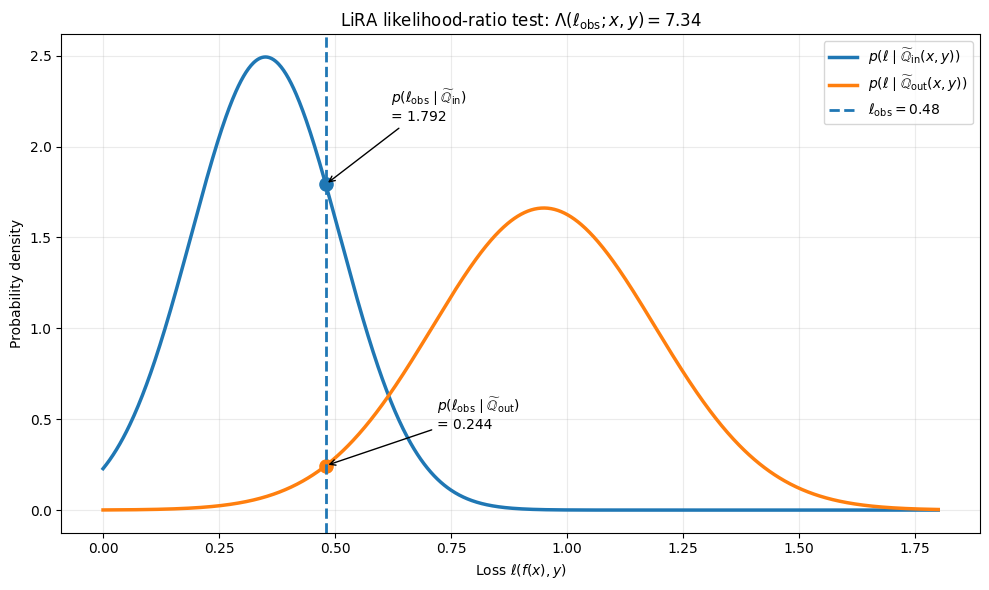

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ------------------------------------------------------------
# LiRA notation
#
# Observed target-model loss:
#   ℓ_obs = ℓ(f(x), y)
#
# Member-loss distribution:
#   ℓ | H_in  ~  Q̃_in(x, y)  ≈  N(μ_in, σ_in²)
#
# Non-member-loss distribution:
#   ℓ | H_out ~  Q̃_out(x, y) ≈  N(μ_out, σ_out²)
#
# Likelihood ratio:
#                 p(ℓ_obs | Q̃_in(x, y))
#   Λ(ℓ_obs;x,y) = ----------------------
#                 p(ℓ_obs | Q̃_out(x, y))
# ------------------------------------------------------------

mu_in = 0.35
sigma_in = 0.16

mu_out = 0.95
sigma_out = 0.24

ell_obs = 0.48
tau = 1.0

ell_values = np.linspace(0.0, 1.8, 1000)

q_tilde_in = norm.pdf(
    ell_values,
    loc=mu_in,
    scale=sigma_in
)

q_tilde_out = norm.pdf(
    ell_values,
    loc=mu_out,
    scale=sigma_out
)

p_ell_given_q_in = norm.pdf(
    ell_obs,
    loc=mu_in,
    scale=sigma_in
)

p_ell_given_q_out = norm.pdf(
    ell_obs,
    loc=mu_out,
    scale=sigma_out
)

likelihood_ratio = p_ell_given_q_in / p_ell_given_q_out

membership_prediction = (
    "Member"
    if likelihood_ratio > tau
    else "Non-member"
)

print(f"ℓ_obs = {ell_obs:.4f}")
print(
    "p(ℓ_obs | Q̃_in(x,y)) = "
    f"{p_ell_given_q_in:.6f}"
)
print(
    "p(ℓ_obs | Q̃_out(x,y)) = "
    f"{p_ell_given_q_out:.6f}"
)
print(f"Λ(ℓ_obs;x,y) = {likelihood_ratio:.6f}")
print(f"Prediction = {membership_prediction}")

plt.figure(figsize=(10, 6))

plt.plot(
    ell_values,
    q_tilde_in,
    linewidth=2.5,
    label=(
        r"$p(\ell\mid\widetilde{\mathbb{Q}}_{\mathrm{in}}"
        r"(x,y))$"
    )
)

plt.plot(
    ell_values,
    q_tilde_out,
    linewidth=2.5,
    label=(
        r"$p(\ell\mid\widetilde{\mathbb{Q}}_{\mathrm{out}}"
        r"(x,y))$"
    )
)

plt.axvline(
    ell_obs,
    linestyle="--",
    linewidth=2,
    label=rf"$\ell_{{\mathrm{{obs}}}}={ell_obs}$"
)

plt.scatter(
    ell_obs,
    p_ell_given_q_in,
    s=90
)

plt.scatter(
    ell_obs,
    p_ell_given_q_out,
    s=90
)

plt.annotate(
    (
        r"$p(\ell_{\mathrm{obs}}\mid"
        r"\widetilde{\mathbb{Q}}_{\mathrm{in}})$"
        f"\n= {p_ell_given_q_in:.3f}"
    ),
    xy=(ell_obs, p_ell_given_q_in),
    xytext=(0.62, p_ell_given_q_in + 0.35),
    arrowprops={"arrowstyle": "->"}
)

plt.annotate(
    (
        r"$p(\ell_{\mathrm{obs}}\mid"
        r"\widetilde{\mathbb{Q}}_{\mathrm{out}})$"
        f"\n= {p_ell_given_q_out:.3f}"
    ),
    xy=(ell_obs, p_ell_given_q_out),
    xytext=(0.72, p_ell_given_q_out + 0.2),
    arrowprops={"arrowstyle": "->"}
)

plt.xlabel(r"Loss $\ell(f(x),y)$")
plt.ylabel("Probability density")

plt.title(
    r"LiRA likelihood-ratio test: "
    rf"$\Lambda(\ell_{{\mathrm{{obs}}}};x,y)"
    rf"={likelihood_ratio:.2f}$"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ℓ_obs = 0.25
p(ℓ_obs | Q̃_in(x,y)) = 4.8394144904
p(ℓ_obs | Q̃_out(x,y)) = 0.0088365865
Λ(ℓ_obs;x,y) = 547.6565506710
Prediction = Member


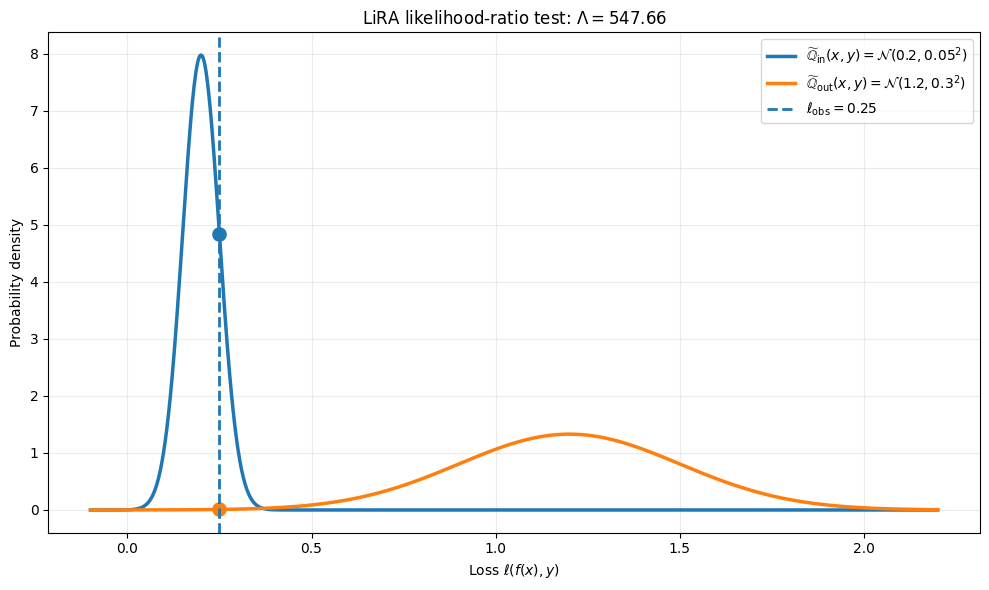

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Observed target-model loss:
# ℓ_obs = ℓ(f(x), y) = 0.25
ell_obs = 0.25

# Member-loss distribution:
# Q̃_in(x,y) = N(μ_in, σ_in²) = N(0.2, 0.05²)
mu_in = 0.2
sigma_in = 0.05

# Non-member-loss distribution:
# Q̃_out(x,y) = N(μ_out, σ_out²) = N(1.2, 0.3²)
mu_out = 1.2
sigma_out = 0.3

tau = 1.0

ell_values = np.linspace(-0.1, 2.2, 1000)

p_ell_given_q_in_curve = norm.pdf(
    ell_values,
    loc=mu_in,
    scale=sigma_in
)

p_ell_given_q_out_curve = norm.pdf(
    ell_values,
    loc=mu_out,
    scale=sigma_out
)

p_ell_obs_given_q_in = norm.pdf(
    ell_obs,
    loc=mu_in,
    scale=sigma_in
)

p_ell_obs_given_q_out = norm.pdf(
    ell_obs,
    loc=mu_out,
    scale=sigma_out
)

likelihood_ratio = (
    p_ell_obs_given_q_in /
    p_ell_obs_given_q_out
)

prediction = (
    "Member"
    if likelihood_ratio > tau
    else "Non-member"
)

print(f"ℓ_obs = {ell_obs}")
print(
    f"p(ℓ_obs | Q̃_in(x,y)) = "
    f"{p_ell_obs_given_q_in:.10f}"
)
print(
    f"p(ℓ_obs | Q̃_out(x,y)) = "
    f"{p_ell_obs_given_q_out:.10f}"
)
print(
    f"Λ(ℓ_obs;x,y) = "
    f"{likelihood_ratio:.10f}"
)
print(f"Prediction = {prediction}")

plt.figure(figsize=(10, 6))

plt.plot(
    ell_values,
    p_ell_given_q_in_curve,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{in}}(x,y)"
        r"=\mathcal{N}(0.2,0.05^2)$"
    )
)

plt.plot(
    ell_values,
    p_ell_given_q_out_curve,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{out}}(x,y)"
        r"=\mathcal{N}(1.2,0.3^2)$"
    )
)

plt.axvline(
    ell_obs,
    linestyle="--",
    linewidth=2,
    label=r"$\ell_{\mathrm{obs}}=0.25$"
)

plt.scatter(
    ell_obs,
    p_ell_obs_given_q_in,
    s=90
)

plt.scatter(
    ell_obs,
    p_ell_obs_given_q_out,
    s=90
)

plt.xlabel(r"Loss $\ell(f(x),y)$")
plt.ylabel("Probability density")

plt.title(
    r"LiRA likelihood-ratio test: "
    rf"$\Lambda={likelihood_ratio:.2f}$"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

ℓ_obs = 0.25
p(ℓ_obs | Q̃_in(x,y)) = 3.847299313353e-21
p(ℓ_obs | Q̃_out(x,y)) = 5.139886785834e-17
Λ(ℓ_obs; x,y) = 0.000074851830
Prediction = Non-member


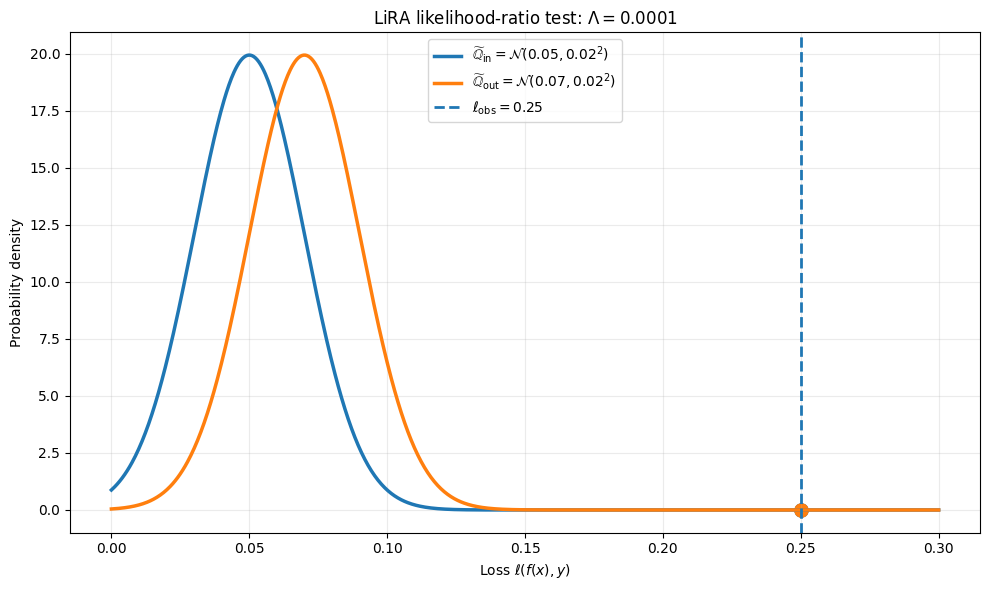

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Observed target-model loss:
# ℓ_obs = ℓ(f(x), y) = 0.25
ell_obs = 0.25

# Member-loss distribution:
# Q̃_in(x,y) = N(μ_in, σ_in²) = N(0.05, 0.02²)
mu_in = 0.05
sigma_in = 0.02

# Non-member-loss distribution:
# Q̃_out(x,y) = N(μ_out, σ_out²) = N(0.07, 0.02²)
mu_out = 0.07
sigma_out = 0.02

tau = 1.0

ell_values = np.linspace(0.0, 0.30, 1000)

density_in = norm.pdf(
    ell_values,
    loc=mu_in,
    scale=sigma_in
)

density_out = norm.pdf(
    ell_values,
    loc=mu_out,
    scale=sigma_out
)

p_ell_obs_given_q_in = norm.pdf(
    ell_obs,
    loc=mu_in,
    scale=sigma_in
)

p_ell_obs_given_q_out = norm.pdf(
    ell_obs,
    loc=mu_out,
    scale=sigma_out
)

likelihood_ratio = (
    p_ell_obs_given_q_in
    / p_ell_obs_given_q_out
)

prediction = (
    "Member"
    if likelihood_ratio > tau
    else "Non-member"
)

print(f"ℓ_obs = {ell_obs}")
print(
    "p(ℓ_obs | Q̃_in(x,y)) = "
    f"{p_ell_obs_given_q_in:.12e}"
)
print(
    "p(ℓ_obs | Q̃_out(x,y)) = "
    f"{p_ell_obs_given_q_out:.12e}"
)
print(
    "Λ(ℓ_obs; x,y) = "
    f"{likelihood_ratio:.12f}"
)
print(f"Prediction = {prediction}")

plt.figure(figsize=(10, 6))

plt.plot(
    ell_values,
    density_in,
    linewidth=2.5,
    label=r"$\widetilde{\mathbb{Q}}_{\mathrm{in}}"
          r"=\mathcal{N}(0.05,0.02^2)$"
)

plt.plot(
    ell_values,
    density_out,
    linewidth=2.5,
    label=r"$\widetilde{\mathbb{Q}}_{\mathrm{out}}"
          r"=\mathcal{N}(0.07,0.02^2)$"
)

plt.axvline(
    ell_obs,
    linestyle="--",
    linewidth=2,
    label=r"$\ell_{\mathrm{obs}}=0.25$"
)

plt.scatter(
    ell_obs,
    p_ell_obs_given_q_in,
    s=90
)

plt.scatter(
    ell_obs,
    p_ell_obs_given_q_out,
    s=90
)

plt.xlabel(r"Loss $\ell(f(x),y)$")
plt.ylabel("Probability density")

plt.title(
    r"LiRA likelihood-ratio test: "
    rf"$\Lambda={likelihood_ratio:.4f}$"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



Example A
ℓ_A = 0.06
p(ℓ_A | Q̃_in^A)  = 24.19707245
p(ℓ_A | Q̃_out^A) = 5.39909665
Λ_A = 4.48168907

Example B
ℓ_B = 0.4
p(ℓ_B | Q̃_in^B)  = 1.07981933e+00
p(ℓ_B | Q̃_out^B) = 8.85433970e-07
Λ_B = 1.21953682e+06


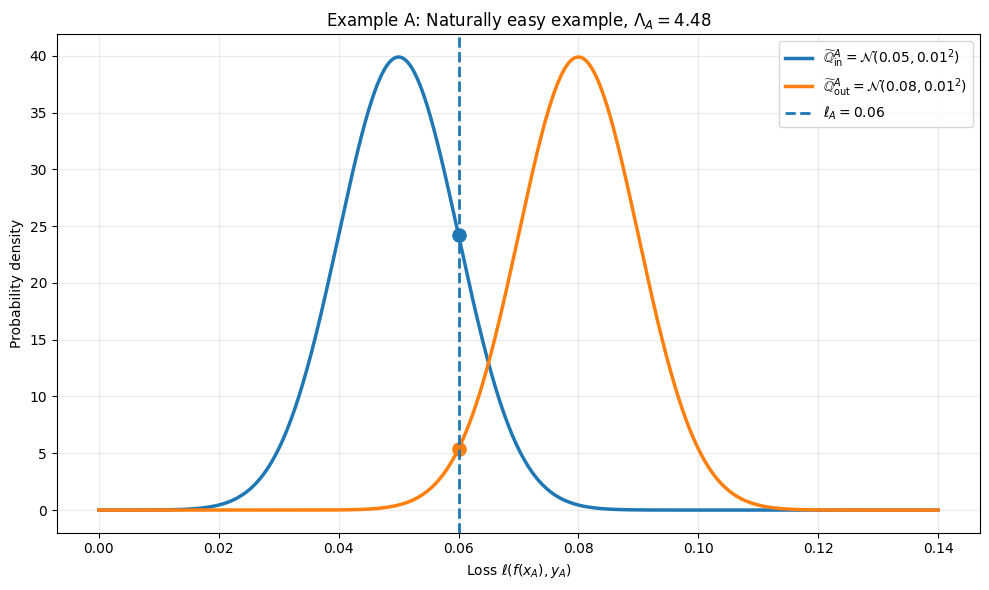

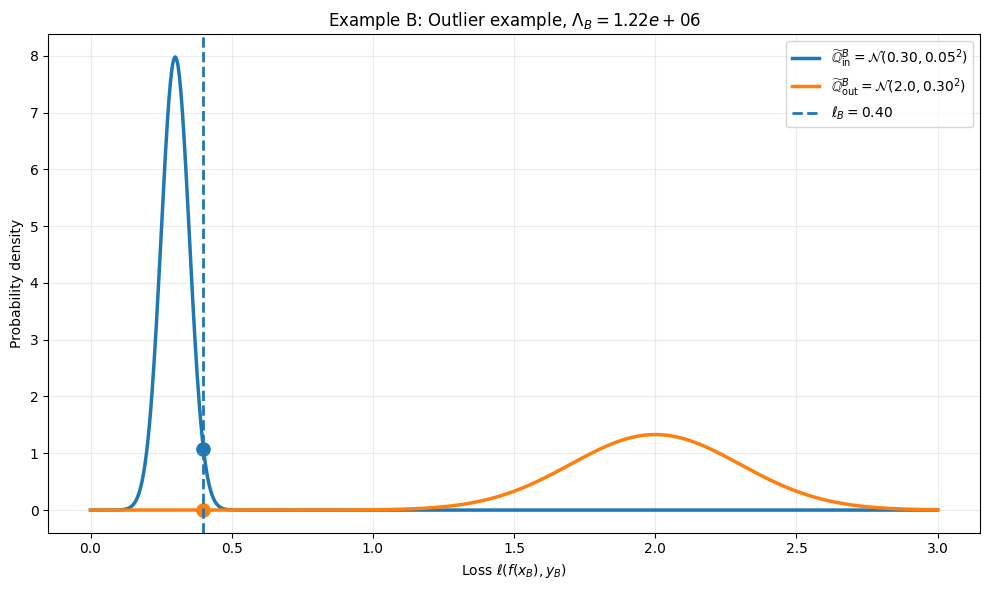

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# Example A: Naturally easy example
# ============================================================

ell_A = 0.06

mu_in_A = 0.05
sigma_in_A = 0.01

mu_out_A = 0.08
sigma_out_A = 0.01

p_A_in = norm.pdf(
    ell_A,
    loc=mu_in_A,
    scale=sigma_in_A
)

p_A_out = norm.pdf(
    ell_A,
    loc=mu_out_A,
    scale=sigma_out_A
)

lambda_A = p_A_in / p_A_out


# ============================================================
# Example B: Outlier example
# ============================================================

ell_B = 0.40

mu_in_B = 0.30
sigma_in_B = 0.05

mu_out_B = 2.0
sigma_out_B = 0.30

p_B_in = norm.pdf(
    ell_B,
    loc=mu_in_B,
    scale=sigma_in_B
)

p_B_out = norm.pdf(
    ell_B,
    loc=mu_out_B,
    scale=sigma_out_B
)

lambda_B = p_B_in / p_B_out


# ============================================================
# Print LiRA likelihood-ratio results
# ============================================================

print("Example A")
print(f"ℓ_A = {ell_A}")
print(f"p(ℓ_A | Q̃_in^A)  = {p_A_in:.8f}")
print(f"p(ℓ_A | Q̃_out^A) = {p_A_out:.8f}")
print(f"Λ_A = {lambda_A:.8f}")
print()

print("Example B")
print(f"ℓ_B = {ell_B}")
print(f"p(ℓ_B | Q̃_in^B)  = {p_B_in:.8e}")
print(f"p(ℓ_B | Q̃_out^B) = {p_B_out:.8e}")
print(f"Λ_B = {lambda_B:.8e}")


# ============================================================
# Plot Example A
# ============================================================

loss_values_A = np.linspace(0.0, 0.14, 1000)

density_in_A = norm.pdf(
    loss_values_A,
    loc=mu_in_A,
    scale=sigma_in_A
)

density_out_A = norm.pdf(
    loss_values_A,
    loc=mu_out_A,
    scale=sigma_out_A
)

plt.figure(figsize=(10, 6))

plt.plot(
    loss_values_A,
    density_in_A,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{in}}^A"
        r"=\mathcal{N}(0.05,0.01^2)$"
    )
)

plt.plot(
    loss_values_A,
    density_out_A,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{out}}^A"
        r"=\mathcal{N}(0.08,0.01^2)$"
    )
)

plt.axvline(
    ell_A,
    linestyle="--",
    linewidth=2,
    label=r"$\ell_A=0.06$"
)

plt.scatter(
    ell_A,
    p_A_in,
    s=90
)

plt.scatter(
    ell_A,
    p_A_out,
    s=90
)

plt.xlabel(r"Loss $\ell(f(x_A),y_A)$")
plt.ylabel("Probability density")

plt.title(
    r"Example A: Naturally easy example, "
    rf"$\Lambda_A={lambda_A:.2f}$"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# Plot Example B
# ============================================================

loss_values_B = np.linspace(0.0, 3.0, 1200)

density_in_B = norm.pdf(
    loss_values_B,
    loc=mu_in_B,
    scale=sigma_in_B
)

density_out_B = norm.pdf(
    loss_values_B,
    loc=mu_out_B,
    scale=sigma_out_B
)

plt.figure(figsize=(10, 6))

plt.plot(
    loss_values_B,
    density_in_B,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{in}}^B"
        r"=\mathcal{N}(0.30,0.05^2)$"
    )
)

plt.plot(
    loss_values_B,
    density_out_B,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{out}}^B"
        r"=\mathcal{N}(2.0,0.30^2)$"
    )
)

plt.axvline(
    ell_B,
    linestyle="--",
    linewidth=2,
    label=r"$\ell_B=0.40$"
)

plt.scatter(
    ell_B,
    p_B_in,
    s=90
)

plt.scatter(
    ell_B,
    p_B_out,
    s=90
)

plt.xlabel(r"Loss $\ell(f(x_B),y_B)$")
plt.ylabel("Probability density")

plt.title(
    r"Example B: Outlier example, "
    rf"$\Lambda_B={lambda_B:.2e}$"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



Example A
ℓ_A = 0.06
p(ℓ_A | Q̃_in^A)  = 24.19707245
p(ℓ_A | Q̃_out^A) = 5.39909665
Λ_A = 4.48168907



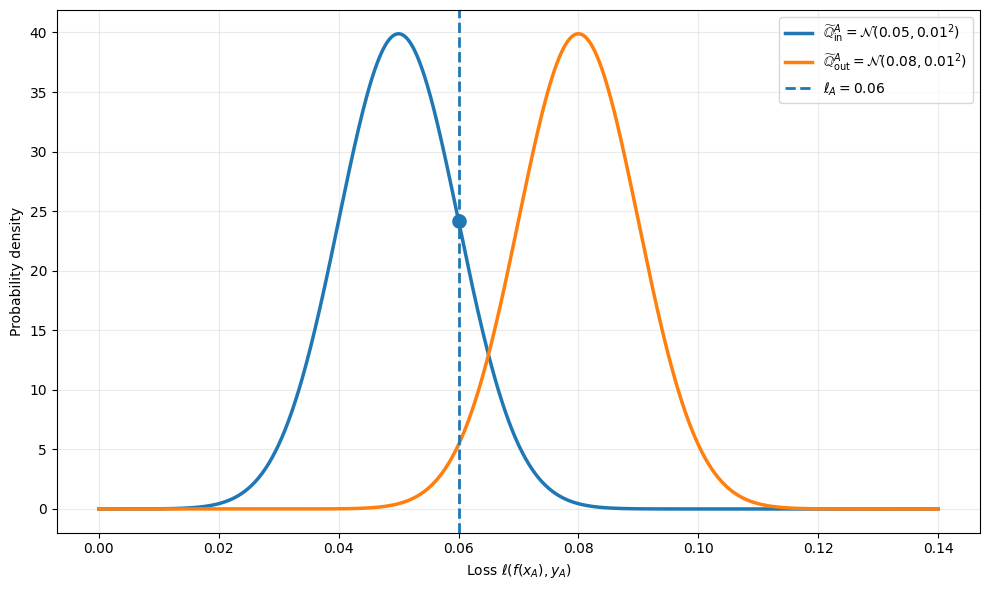

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# Example A: Naturally easy example
# ============================================================

ell_A = 0.06

mu_in_A = 0.05
sigma_in_A = 0.01

mu_out_A = 0.08
sigma_out_A = 0.01

p_A_in = norm.pdf(
    ell_A,
    loc=mu_in_A,
    scale=sigma_in_A
)

p_A_out = norm.pdf(
    ell_A,
    loc=mu_out_A,
    scale=sigma_out_A
)

lambda_A = p_A_in / p_A_out


# ============================================================
# Print LiRA likelihood-ratio results
# ============================================================

print("Example A")
print(f"ℓ_A = {ell_A}")
print(f"p(ℓ_A | Q̃_in^A)  = {p_A_in:.8f}")
print(f"p(ℓ_A | Q̃_out^A) = {p_A_out:.8f}")
print(f"Λ_A = {lambda_A:.8f}")
print()


# ============================================================
# Plot Example A
# ============================================================

loss_values_A = np.linspace(0.0, 0.14, 1000)

density_in_A = norm.pdf(
    loss_values_A,
    loc=mu_in_A,
    scale=sigma_in_A
)

density_out_A = norm.pdf(
    loss_values_A,
    loc=mu_out_A,
    scale=sigma_out_A
)

plt.figure(figsize=(10, 6))

plt.plot(
    loss_values_A,
    density_in_A,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{in}}^A"
        r"=\mathcal{N}(0.05,0.01^2)$"
    )
)

plt.plot(
    loss_values_A,
    density_out_A,
    linewidth=2.5,
    label=(
        r"$\widetilde{\mathbb{Q}}_{\mathrm{out}}^A"
        r"=\mathcal{N}(0.08,0.01^2)$"
    )
)

plt.axvline(
    ell_A,
    linestyle="--",
    linewidth=2,
    label=r"$\ell_A=0.06$"
)

plt.scatter(
    ell_A,
    p_A_in,
    s=90
)




plt.xlabel(r"Loss $\ell(f(x_A),y_A)$")
plt.ylabel("Probability density")


plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



Example A
ℓ_A = 0.06
p(ℓ_A | Q̃_in^A)  = 24.19707245
p(ℓ_A | Q̃_out^A) = 5.39909665
Λ_A = 4.48168907



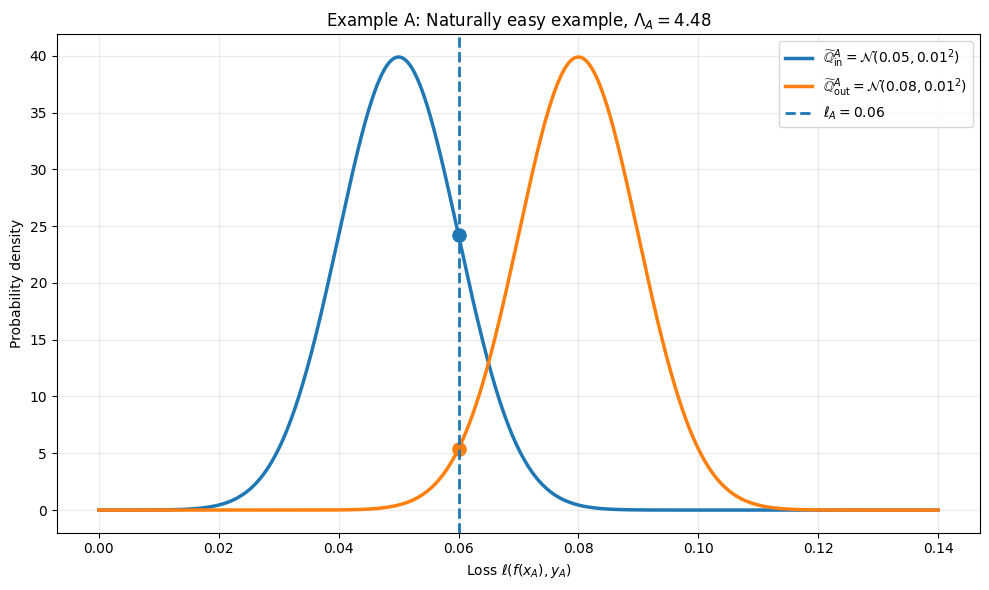